Prophet Model

Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']
Train length: 1461
Test length : 320


16:13:10 - cmdstanpy - INFO - Chain [1] start processing
16:13:10 - cmdstanpy - INFO - Chain [1] done processing



--- METRIKEN (Prophet mit Features) ---
MSE          : 11119441.85
RMSE         : 3334.58
R²           : 0.6992
MAE          : 2494.50
Relative MSE : 0.3838
MAPE         : 22.76%


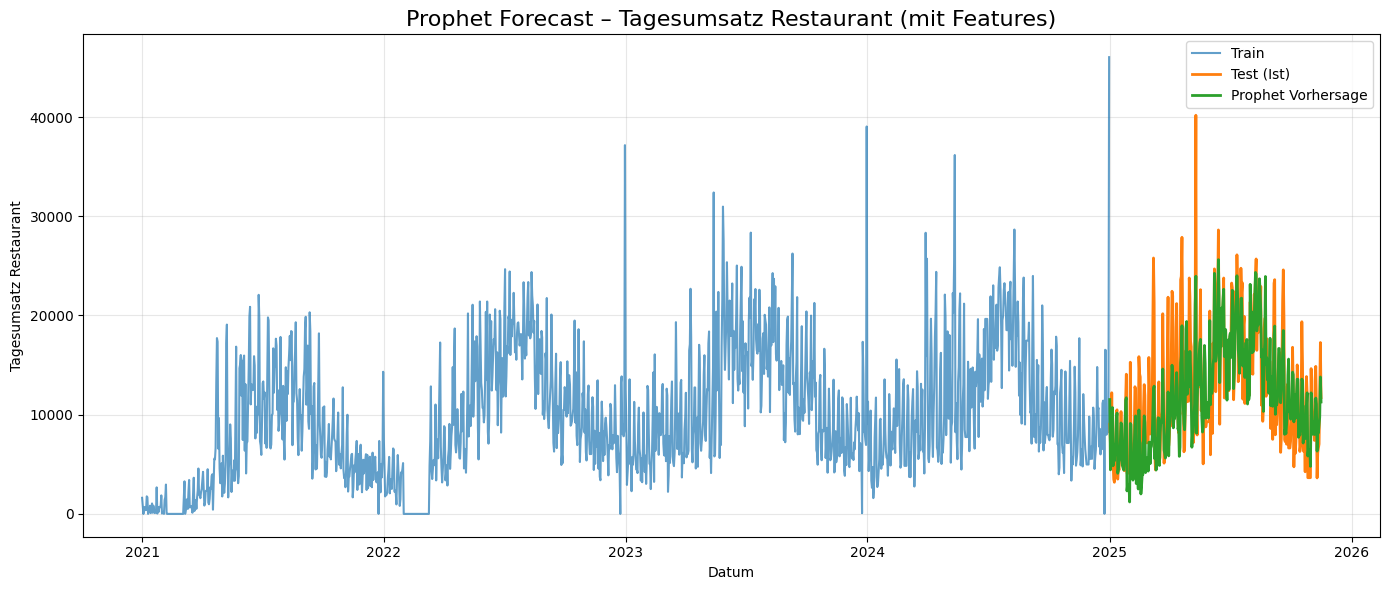

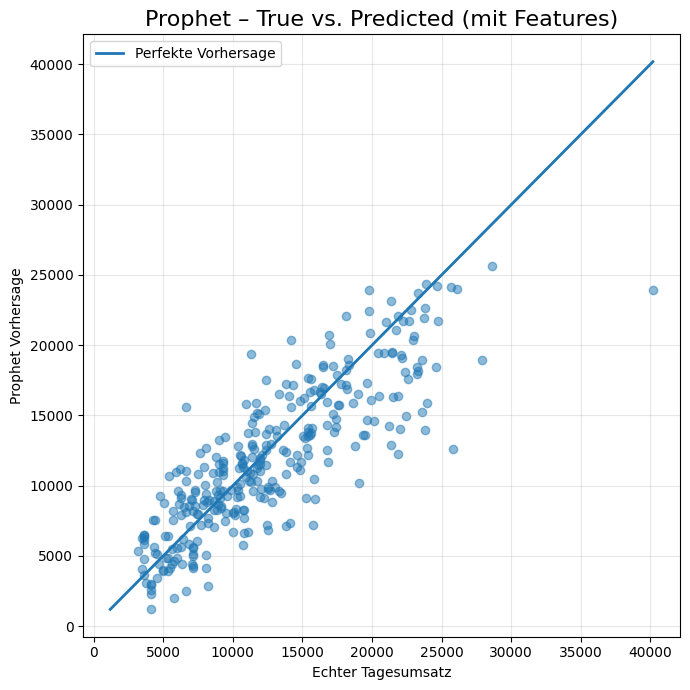

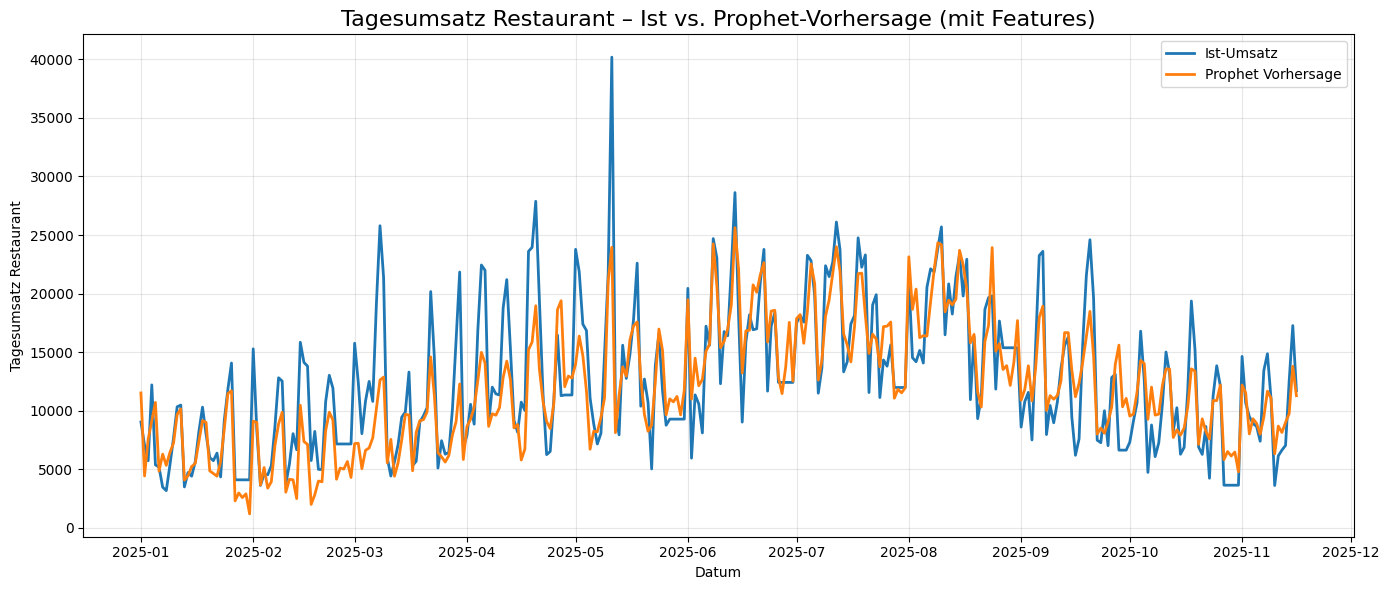

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

target_col = "Tagesumsatz Restaurant"

# 2) Zeitreihe mit allen Features vorbereiten
# tägliche Frequenz + Lücken füllen
df = df.set_index("Datum").asfreq("D")
df = df.ffill().bfill()

# alle numerischen Spalten
num_cols = df.select_dtypes(include=["number"]).columns

# Ziel + Regressoren
regressors = [c for c in num_cols if c != target_col]

print("Zielvariable:", target_col)
print("Regressoren :", regressors)

# Prophet-DataFrame: ds, y, plus alle Regressoren
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})

# 3) Train/Test-Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")
train = df_p[df_p["ds"] < split_date].copy()
test  = df_p[df_p["ds"] >= split_date].copy()

print("Train length:", len(train))
print("Test length :", len(test))

# 4) Prophet-Modell definieren und Regressoren hinzufügen
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# alle numerischen Zusatzfeatures als Regressoren
for reg in regressors:
    m.add_regressor(reg)

# 5) Modell fitten (train enthält y + alle regressors)
m.fit(train[["ds", "y"] + regressors])

# 6) Zukunfts-DataFrame erzeugen (Train + Test Zeitraum)
future = m.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# future mit Regressoren befüllen (aus df_p)
future = future.merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_all = m.predict(future)

# Nur die Testperiode herausholen
forecast_test = forecast_all[forecast_all["ds"] >= split_date].copy()
forecast_test = forecast_test.set_index("ds").loc[test["ds"]].reset_index()

# 7) Metriken berechnen
y_true = test["y"].values
y_pred = forecast_test["yhat"].values

mse  = mean_squared_error(y_true, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)

# Naive Baseline: Vortag als Prognose
full_series = df_p.set_index("ds")["y"]
test_series = full_series.loc[test["ds"]]
y_naive = test_series.shift(1).bfill().values

mse_naive = mean_squared_error(y_true, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_true, y_pred)

print("\n--- METRIKEN (Prophet mit Features) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# 8) Zeitreihen-Plot: Train, Test, Prophet-Vorhersage
plt.figure(figsize=(14,6))
plt.plot(train["ds"], train["y"], label="Train", alpha=0.7)
plt.plot(test["ds"], test["y"], label="Test (Ist)", linewidth=2)
plt.plot(forecast_test["ds"], forecast_test["yhat"], label="Prophet Vorhersage", linewidth=2)

plt.title("Prophet Forecast – Tagesumsatz Restaurant (mit Features)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Scatter-Plot: True vs. Predicted
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.5)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("Prophet – True vs. Predicted (mit Features)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Prophet Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10) Kompakter Test-Plot: Ist vs. Prophet-Vorhersage
results_prophet = pd.DataFrame({
    "Datum": test["ds"],
    "Ist": y_true,
    "Vorhersage": y_pred
})

plt.figure(figsize=(14,6))
plt.plot(results_prophet["Datum"], results_prophet["Ist"],
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. Prophet-Vorhersage (mit Features)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
